<a href="https://colab.research.google.com/github/arpnaahuja/arpna_development/blob/Arapna_Development/Copy_of_updated_Federated_verses_centralized.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


Federated MLP
Round 1: Acc=0.6906, Prec=0.7283, Rec=0.8709, F1=0.7933, AUC=0.5305, Time=8.41s
Round 2: Acc=0.7523, Prec=0.7549, Rec=0.9424, F1=0.8383, AUC=0.6717, Time=0.34s
Round 3: Acc=0.7778, Prec=0.7722, Rec=0.9561, F1=0.8544, AUC=0.7777, Time=0.80s
Round 4: Acc=0.7933, Prec=0.7834, Rec=0.9628, F1=0.8639, AUC=0.8467, Time=0.42s
Round 5: Acc=0.8027, Prec=0.7908, Rec=0.9662, F1=0.8697, AUC=0.8858, Time=0.72s

Federated LSTM
Round 1: Acc=0.2541, Prec=0.2460, Rec=0.0457, F1=0.0771, AUC=0.2801, Time=2.77s
Round 2: Acc=0.2849, Prec=0.3687, Rec=0.0691, F1=0.1164, AUC=0.4365, Time=1.84s
Round 3: Acc=0.3439, Prec=0.5728, Rec=0.1464, F1=0.2333, AUC=0.5869, Time=1.88s
Round 4: Acc=0.5384, Prec=0.7965, Rec=0.4334, F1=0.5614, AUC=0.6695, Time=2.21s
Round 5: Acc=0.6323, Prec=0.8322, Rec=0.5768, F1=0.6813, AUC=0.7553, Time=2.26s

Federated Autoencoder
Round 1: Acc=0.3651, Prec=0.6457, Rec=0.1517, F1=0.2456, AUC=0.4250, Time=0.28s
Round 2: Acc=0.3645, Prec=0.6434, Rec=0.1515, F1=0.2453, AUC=0.422

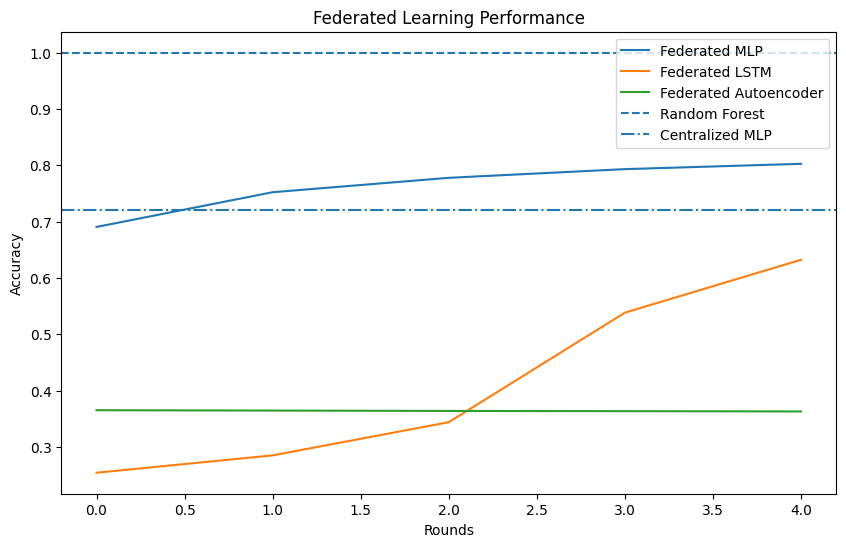

In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import time

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# -----------------------------
# 1. LOAD DATASET
# -----------------------------
data = pd.read_csv("/content/UNSW_NB15_training-set.csv")
data = data.drop(columns=['id'], errors='ignore')

# Encode categorical
for col in data.select_dtypes(include=['object']).columns:
    data[col] = LabelEncoder().fit_transform(data[col])

X = data.drop(columns=['label'])
y = data['label']

# Normalize
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Convert to tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train.values, dtype=torch.long)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test.values, dtype=torch.long)

# -----------------------------
# 2. SIMULATE CLIENTS (NON-IID)
# -----------------------------
num_clients = 3
client_data = []

# Non-IID split: each client gets different class ratios
classes = y_train.unique()
for i in range(num_clients):
    indices = []
    for c in classes:
        class_idx = (y_train == c).nonzero(as_tuple=True)[0]
        size = int(len(class_idx) / num_clients * (0.8 + 0.2*np.random.rand()))
        indices.extend(class_idx[:size].tolist())
    X_c = X_train[indices]
    y_c = y_train[indices]
    client_data.append((X_c, y_c))

# -----------------------------
# 3. MODELS
# -----------------------------
class MLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 2)
        )
    def forward(self, x):
        return self.net(x)

class LSTMModel(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, 32, batch_first=True)
        self.fc = nn.Linear(32, 2)
    def forward(self, x):
        x = x.unsqueeze(1)
        _, (h, _) = self.lstm(x)
        return self.fc(h[-1])

class Autoencoder(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.encoder = nn.Linear(input_dim, 32)
        self.decoder = nn.Linear(32, input_dim)
    def forward(self, x):
        encoded = torch.relu(self.encoder(x))
        decoded = self.decoder(encoded)
        return decoded

# -----------------------------
# 4. LOCAL TRAINING
# -----------------------------
def train_local(model, data, epochs=2, autoencoder=False):
    X, y = data
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    loss_fn = nn.MSELoss() if autoencoder else nn.CrossEntropyLoss()

    model.train()
    for _ in range(epochs):
        optimizer.zero_grad()
        output = model(X)
        loss = loss_fn(output, X if autoencoder else y)
        loss.backward()
        optimizer.step()
    return model.state_dict()

# -----------------------------
# 5. FEDERATED AVERAGING
# -----------------------------
def federated_avg(global_model, client_states):
    global_dict = global_model.state_dict()
    for key in global_dict.keys():
        global_dict[key] = torch.stack([client_states[i][key] for i in range(len(client_states))]).mean(0)
    global_model.load_state_dict(global_dict)

# -----------------------------
# 6. FEDERATED TRAINING
# -----------------------------
def federated_training(model_class, autoencoder=False, rounds=5):
    global_model = model_class(X_train.shape[1])
    acc_list, metrics_list, times = [], [], []

    best_acc = 0
    for r in range(rounds):
        client_states = []
        start_time = time.time()

        for client in client_data:
            local_model = model_class(X_train.shape[1])
            local_model.load_state_dict(global_model.state_dict())
            weights = train_local(local_model, client, autoencoder=autoencoder)
            client_states.append(weights)

        federated_avg(global_model, client_states)

        # Evaluate
        global_model.eval()
        with torch.no_grad():
            if autoencoder:
                recon = global_model(X_test)
                loss = ((X_test - recon) ** 2).mean(dim=1)
                preds = (loss > loss.mean()).int()
                # ROC-AUC
                auc = roc_auc_score(y_test, loss.detach().numpy())
            else:
                output = global_model(X_test)
                preds = output.argmax(dim=1)
                auc = roc_auc_score(y_test, torch.softmax(output, dim=1)[:,1])

        acc = accuracy_score(y_test, preds)
        prec = precision_score(y_test, preds)
        rec = recall_score(y_test, preds)
        f1 = f1_score(y_test, preds)
        cm = confusion_matrix(y_test, preds)

        acc_list.append(acc)
        metrics_list.append((acc, prec, rec, f1, auc, cm))
        times.append(time.time() - start_time)

        if acc > best_acc:
            best_acc = acc
            torch.save(global_model.state_dict(), f"best_model_{model_class.__name__}.pt")

        print(f"Round {r+1}: Acc={acc:.4f}, Prec={prec:.4f}, Rec={rec:.4f}, F1={f1:.4f}, AUC={auc:.4f}, Time={times[-1]:.2f}s")

    return global_model, acc_list, metrics_list, times

# -----------------------------
# 7. CENTRALIZED TRAINING
# -----------------------------
def centralized_training(model_class=MLP, epochs=5):
    model = model_class(X_train.shape[1])
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    loss_fn = nn.CrossEntropyLoss()

    for _ in range(epochs):
        optimizer.zero_grad()
        output = model(X_train)
        loss = loss_fn(output, y_train)
        loss.backward()
        optimizer.step()

    with torch.no_grad():
        output = model(X_test)
        preds = output.argmax(dim=1)

    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds)
    rec = recall_score(y_test, preds)
    f1 = f1_score(y_test, preds)
    auc = roc_auc_score(y_test, torch.softmax(output, dim=1)[:,1])
    cm = confusion_matrix(y_test, preds)

    return acc, prec, rec, f1, auc, cm

# -----------------------------
# 8. RANDOM FOREST
# -----------------------------
rf = RandomForestClassifier()
rf.fit(X_train.numpy(), y_train.numpy())
rf_preds = rf.predict(X_test.numpy())

rf_acc = accuracy_score(y_test, rf_preds)
rf_prec = precision_score(y_test, rf_preds)
rf_rec = recall_score(y_test, rf_preds)
rf_f1 = f1_score(y_test, rf_preds)
rf_auc = roc_auc_score(y_test, rf_preds)
rf_cm = confusion_matrix(y_test, rf_preds)

# -----------------------------
# 9. RUN FEDERATED MODELS
# -----------------------------
print("\nFederated MLP")
mlp_model, mlp_acc, mlp_metrics, mlp_times = federated_training(MLP)

print("\nFederated LSTM")
lstm_model, lstm_acc, lstm_metrics, lstm_times = federated_training(LSTMModel)

print("\nFederated Autoencoder")
ae_model, ae_acc, ae_metrics, ae_times = federated_training(Autoencoder, autoencoder=True)

# -----------------------------
# 10. CENTRALIZED TRAINING
# -----------------------------
central_acc, central_prec, central_rec, central_f1, central_auc, central_cm = centralized_training()

# -----------------------------
# 11. COMPARISON TABLE
# -----------------------------
import pandas as pd
table = pd.DataFrame({
    'Model': ['Federated MLP', 'Federated LSTM', 'Federated Autoencoder', 'Random Forest', 'Centralized MLP'],
    'Accuracy': [mlp_metrics[-1][0], lstm_metrics[-1][0], ae_metrics[-1][0], rf_acc, central_acc],
    'Precision': [mlp_metrics[-1][1], lstm_metrics[-1][1], ae_metrics[-1][1], rf_prec, central_prec],
    'Recall': [mlp_metrics[-1][2], lstm_metrics[-1][2], ae_metrics[-1][2], rf_rec, central_rec],
    'F1': [mlp_metrics[-1][3], lstm_metrics[-1][3], ae_metrics[-1][3], rf_f1, central_f1],
    'ROC-AUC': [mlp_metrics[-1][4], lstm_metrics[-1][4], ae_metrics[-1][4], rf_auc, central_auc]
})
print("\nComparison Table:\n", table)

# -----------------------------
# 12. VISUALIZATION
# -----------------------------
plt.figure(figsize=(10,6))
plt.plot(mlp_acc, label='Federated MLP')
plt.plot(lstm_acc, label='Federated LSTM')
plt.plot(ae_acc, label='Federated Autoencoder')
plt.axhline(y=rf_acc, linestyle='--', label='Random Forest')
plt.axhline(y=central_acc, linestyle='-.', label='Centralized MLP')
plt.xlabel('Rounds')
plt.ylabel('Accuracy')
plt.title('Federated Learning Performance')
plt.legend()
plt.show()

# -----------------------------
# 13. OPTIONAL: SHAP for Random Forest
# -----------------------------
import shap
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test.numpy())
shap.summary_plot(shap_values, X_test.numpy())

Using device: cuda

Federated MLP
Round 1: Acc=0.9520, Prec=0.9484, Rec=0.9831, F1=0.9654, AUC=0.9934, Time=7.19s
Round 2: Acc=0.9729, Prec=0.9705, Rec=0.9903, F1=0.9803, AUC=0.9976, Time=2.33s
Round 3: Acc=0.9874, Prec=0.9886, Rec=0.9930, F1=0.9908, AUC=0.9992, Time=2.30s

Federated LSTM
Round 1: Acc=0.9310, Prec=0.9147, Rec=0.9911, F1=0.9514, AUC=0.9867, Time=2.74s
Round 2: Acc=0.9638, Prec=0.9649, Rec=0.9826, F1=0.9737, AUC=0.9948, Time=2.63s
Round 3: Acc=0.9775, Prec=0.9791, Rec=0.9882, F1=0.9836, AUC=0.9980, Time=2.64s

Federated Autoencoder
Round 1: Acc=0.3267, Prec=0.5472, Rec=0.0701, F1=0.1243, AUC=0.3990, Time=2.65s
Round 2: Acc=0.3292, Prec=0.5647, Rec=0.0683, F1=0.1218, AUC=0.3770, Time=2.12s
Round 3: Acc=0.3266, Prec=0.5563, Rec=0.0587, F1=0.1062, AUC=0.3802, Time=1.95s

Comparison Table:
                    Model  Accuracy  Precision    Recall        F1   ROC-AUC
0          Federated MLP  0.987425   0.988627  0.992971  0.990794  0.999237
1         Federated LSTM  0.977530 

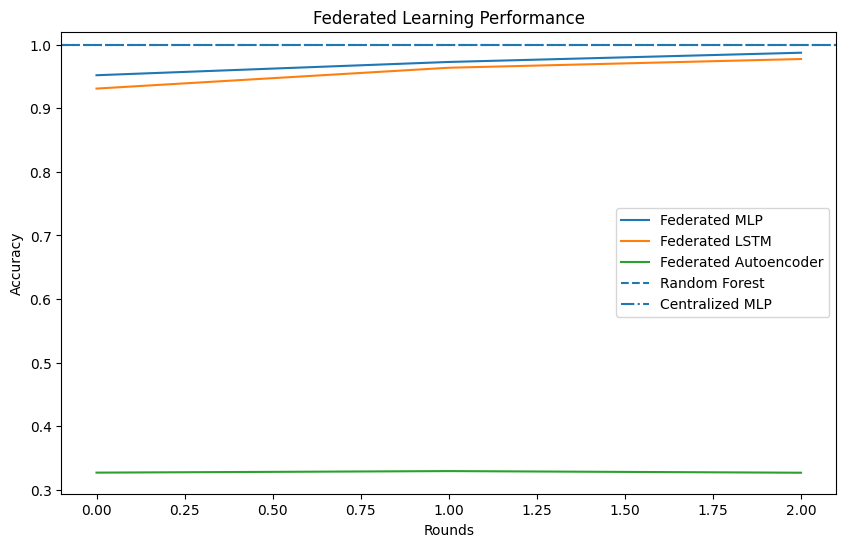

KeyboardInterrupt: 

In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import time

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset, DataLoader

# -----------------------------
# 0. DEVICE
# -----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# -----------------------------
# 1. LOAD DATASET
# -----------------------------
data = pd.read_csv("/content/UNSW_NB15_training-set.csv")
data = data.drop(columns=['id'], errors='ignore')

# Encode categorical
for col in data.select_dtypes(include=['object']).columns:
    data[col] = LabelEncoder().fit_transform(data[col])

X = data.drop(columns=['label'])
y = data['label']

# Normalize
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Convert to tensors and send to device
X_train = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train = torch.tensor(y_train.values, dtype=torch.long).to(device)
X_test = torch.tensor(X_test, dtype=torch.float32).to(device)
y_test = torch.tensor(y_test.values, dtype=torch.long).to(device)

# -----------------------------
# 2. SIMULATE CLIENTS (NON-IID)
# -----------------------------
num_clients = 3
client_data = []
classes = y_train.unique()

for i in range(num_clients):
    indices = []
    for c in classes:
        class_idx = (y_train == c).nonzero(as_tuple=True)[0]
        size = int(len(class_idx) / num_clients * (0.8 + 0.2*np.random.rand()))
        indices.extend(class_idx[:size].tolist())
    X_c = X_train[indices]
    y_c = y_train[indices]
    client_data.append((X_c, y_c))

# -----------------------------
# 3. MODELS
# -----------------------------
class MLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 2)
        )
    def forward(self, x):
        return self.net(x)

class LSTMModel(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, 16, batch_first=True)  # smaller hidden size
        self.fc = nn.Linear(16, 2)
    def forward(self, x):
        x = x.unsqueeze(1)
        _, (h, _) = self.lstm(x)
        return self.fc(h[-1])

class Autoencoder(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.encoder = nn.Linear(input_dim, 32)
        self.decoder = nn.Linear(32, input_dim)
    def forward(self, x):
        encoded = torch.relu(self.encoder(x))
        decoded = self.decoder(encoded)
        return decoded

# -----------------------------
# 4. LOCAL TRAINING WITH BATCHING
# -----------------------------
def train_local(model, data, epochs=2, autoencoder=False, batch_size=128):
    X, y = data
    dataset = TensorDataset(X, X if autoencoder else y)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    loss_fn = nn.MSELoss() if autoencoder else nn.CrossEntropyLoss()

    model.train()
    for _ in range(epochs):
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            output = model(xb)
            loss = loss_fn(output, yb)
            loss.backward()
            optimizer.step()
    return model.state_dict()

# -----------------------------
# 5. FEDERATED AVERAGING
# -----------------------------
def federated_avg(global_model, client_states):
    global_dict = global_model.state_dict()
    for key in global_dict.keys():
        global_dict[key] = torch.stack([client_states[i][key] for i in range(len(client_states))]).mean(0)
    global_model.load_state_dict(global_dict)

# -----------------------------
# 6. FEDERATED TRAINING
# -----------------------------
def federated_training(model_class, autoencoder=False, rounds=3, epochs=1):
    global_model = model_class(X_train.shape[1]).to(device)
    acc_list, metrics_list, times = [], [], []

    best_acc = 0
    for r in range(rounds):
        client_states = []
        start_time = time.time()

        for client in client_data:
            local_model = model_class(X_train.shape[1]).to(device)
            local_model.load_state_dict(global_model.state_dict())
            weights = train_local(local_model, client, autoencoder=autoencoder, epochs=epochs)
            client_states.append(weights)

        federated_avg(global_model, client_states)

        # Evaluate
        global_model.eval()
        with torch.no_grad():
            if autoencoder:
                recon = global_model(X_test)
                loss = ((X_test - recon) ** 2).mean(dim=1)
                preds = (loss > loss.mean()).int()
                auc = roc_auc_score(y_test.cpu(), loss.cpu().numpy())
            else:
                output = global_model(X_test)
                preds = output.argmax(dim=1)
                auc = roc_auc_score(y_test.cpu(), torch.softmax(output, dim=1)[:,1].cpu())

        acc = accuracy_score(y_test.cpu(), preds.cpu())
        prec = precision_score(y_test.cpu(), preds.cpu())
        rec = recall_score(y_test.cpu(), preds.cpu())
        f1 = f1_score(y_test.cpu(), preds.cpu())
        cm = confusion_matrix(y_test.cpu(), preds.cpu())

        acc_list.append(acc)
        metrics_list.append((acc, prec, rec, f1, auc, cm))
        times.append(time.time() - start_time)

        if acc > best_acc:
            best_acc = acc
            torch.save(global_model.state_dict(), f"best_model_{model_class.__name__}.pt")

        print(f"Round {r+1}: Acc={acc:.4f}, Prec={prec:.4f}, Rec={rec:.4f}, F1={f1:.4f}, AUC={auc:.4f}, Time={times[-1]:.2f}s")

    return global_model, acc_list, metrics_list, times

# -----------------------------
# 7. CENTRALIZED TRAINING
# -----------------------------
def centralized_training(model_class=MLP, epochs=5, batch_size=128):
    model = model_class(X_train.shape[1]).to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    loss_fn = nn.CrossEntropyLoss()
    dataset = TensorDataset(X_train, y_train)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    model.train()
    for _ in range(epochs):
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            output = model(xb)
            loss = loss_fn(output, yb)
            loss.backward()
            optimizer.step()

    model.eval()
    with torch.no_grad():
        output = model(X_test)
        preds = output.argmax(dim=1)

    acc = accuracy_score(y_test.cpu(), preds.cpu())
    prec = precision_score(y_test.cpu(), preds.cpu())
    rec = recall_score(y_test.cpu(), preds.cpu())
    f1 = f1_score(y_test.cpu(), preds.cpu())
    auc = roc_auc_score(y_test.cpu(), torch.softmax(output, dim=1)[:,1].cpu())
    cm = confusion_matrix(y_test.cpu(), preds.cpu())

    return acc, prec, rec, f1, auc, cm

# -----------------------------
# 8. RANDOM FOREST
# -----------------------------
rf = RandomForestClassifier(n_jobs=-1)  # parallel
rf.fit(X_train.cpu().numpy(), y_train.cpu().numpy())
rf_preds = rf.predict(X_test.cpu().numpy())

rf_acc = accuracy_score(y_test.cpu(), rf_preds)
rf_prec = precision_score(y_test.cpu(), rf_preds)
rf_rec = recall_score(y_test.cpu(), rf_preds)
rf_f1 = f1_score(y_test.cpu(), rf_preds)
rf_auc = roc_auc_score(y_test.cpu(), rf_preds)
rf_cm = confusion_matrix(y_test.cpu(), rf_preds)

# -----------------------------
# 9. RUN FEDERATED MODELS
# -----------------------------
print("\nFederated MLP")
mlp_model, mlp_acc, mlp_metrics, mlp_times = federated_training(MLP)

print("\nFederated LSTM")
lstm_model, lstm_acc, lstm_metrics, lstm_times = federated_training(LSTMModel)

print("\nFederated Autoencoder")
ae_model, ae_acc, ae_metrics, ae_times = federated_training(Autoencoder, autoencoder=True)

# -----------------------------
# 10. CENTRALIZED TRAINING
# -----------------------------
central_acc, central_prec, central_rec, central_f1, central_auc, central_cm = centralized_training()

# -----------------------------
# 11. COMPARISON TABLE
# -----------------------------
table = pd.DataFrame({
    'Model': ['Federated MLP', 'Federated LSTM', 'Federated Autoencoder', 'Random Forest', 'Centralized MLP'],
    'Accuracy': [mlp_metrics[-1][0], lstm_metrics[-1][0], ae_metrics[-1][0], rf_acc, central_acc],
    'Precision': [mlp_metrics[-1][1], lstm_metrics[-1][1], ae_metrics[-1][1], rf_prec, central_prec],
    'Recall': [mlp_metrics[-1][2], lstm_metrics[-1][2], ae_metrics[-1][2], rf_rec, central_rec],
    'F1': [mlp_metrics[-1][3], lstm_metrics[-1][3], ae_metrics[-1][3], rf_f1, central_f1],
    'ROC-AUC': [mlp_metrics[-1][4], lstm_metrics[-1][4], ae_metrics[-1][4], rf_auc, central_auc]
})
print("\nComparison Table:\n", table)

# -----------------------------
# 12. VISUALIZATION
# -----------------------------
plt.figure(figsize=(10,6))
plt.plot(mlp_acc, label='Federated MLP')
plt.plot(lstm_acc, label='Federated LSTM')
plt.plot(ae_acc, label='Federated Autoencoder')
plt.axhline(y=rf_acc, linestyle='--', label='Random Forest')
plt.axhline(y=central_acc, linestyle='-.', label='Centralized MLP')
plt.xlabel('Rounds')
plt.ylabel('Accuracy')
plt.title('Federated Learning Performance')
plt.legend()
plt.show()

# -----------------------------
# 13. OPTIONAL: SHAP FOR RF (Subset)
# -----------------------------
import shap
X_sample = X_test[:1000].cpu().numpy()
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_sample)
shap.summary_plot(shap_values, X_sample)